# GX_09
# Phase Conjugation in PT Symmetric Systems

In this exercise you will examine the effect of performing phase conjugation on a system that is not Hermitian but is PT symmetric.

In [1]:
# - No modification necessary -

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

In [2]:
# - No modification necessary -

wavelength = 633e-9
N = 256
L = 2e-4
dx = L/N

x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
X, Y = np.meshgrid(x, y)

kx = 2 * np.pi * np.fft.fftfreq(N, d=dx)
ky = 2 * np.pi * np.fft.fftfreq(N, d=dx)
KX, KY = np.meshgrid(kx, ky)
K2 = KX**2 + KY**2

dz = 1e-6
n_steps = 1000
k0 = 2 * np.pi / wavelength

core_radius = 50e-6
gain_radius = 15e-6
gain_offset = 20e-6

w0 = 13.0e-6

# Part 1

In this part of the exercise, you will create a multimode fiber that has a symmetrical gain and loss region. This will act as your non-hermitian but PT symmetric system. 

All the required parameters for the dimensions of the fiber have already been provided. You should build the fiber such that the centers of the gain/loss regions are separated by a distance of 2*gain_offset and each of them has a radius of gain_radius. The total radius of the core will be the provided core_radius value, and you may assume that the cladding extends off past the edge of the simulation domain.

After you have created your fiber, you can visualize it with the provided functions.

Then, answer the following questions:
1) How do we know that this system satisfies PT symmetry?
2) Are we guaranteed to have real eigenvalues with our specified geometry?

In [3]:
def create_multimode_fiber(n_core=1.45, n_clad=1.44, alpha0=5.0):
    """
    Constructs a complex refractive index profile for a multimode optical fiber
    with optional gain/loss regions in the core.

    Parameters
    ----------
    n_core : float
        Refractive index of the fiber core.
    n_clad : float
        Refractive index of the cladding.
    alpha0 : float
        Magnitude of gain/loss coefficient used in the active regions.

    Returns
    -------
    n : ndarray (float)
        Refractive index distribution.
    n_ewd : float
        Reference refractive index value.
    alpha : ndarray (float)
        Spatial gain/loss coefficient distribution.
    """
    r = np.sqrt(X**2 + Y**2)

    n_real = np.ones_like(X) * n_clad
    n_real[r <= core_radius] = n_core

    alpha = np.zeros_like(X)

    gain_region = (X - gain_offset)**2 + Y**2 < gain_radius**2
    alpha[gain_region] = -alpha0

    loss_region = (X + gain_offset)**2 + Y**2 < gain_radius**2
    alpha[loss_region] = +alpha0

    core_mask = r <= core_radius
    alpha *= core_mask

    n_imag = -alpha / (2 * k0)

    n = n_real + 1j * n_imag

    return n, n_clad, alpha

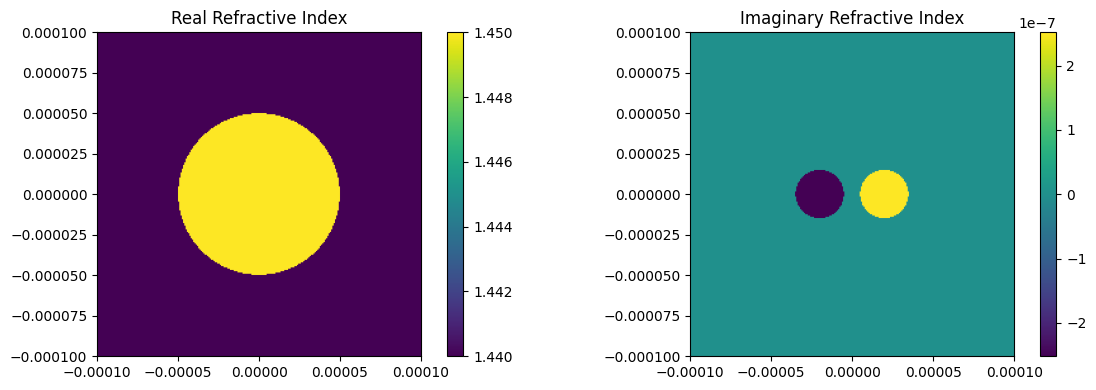

In [4]:
# - No modification necessary -

n, n_ref, alpha = create_multimode_fiber(alpha0=5.0)

def plot_fiber(n):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(np.real(n), extent=[x.min(), x.max(), y.min(), y.max()])
    plt.title("Real Refractive Index")
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.imshow(np.imag(n), extent=[x.min(), x.max(), y.min(), y.max()])
    plt.title("Imaginary Refractive Index")
    plt.colorbar()

    plt.tight_layout()
    plt.show()

plot_fiber(n)

## Discussion
1) To satisfy PT symmetry, we must have a system that is symmetric in real potential and asymmetric in imaginary potential. For our optical system, potential is equivalent to refractive index, which we know we have defined to satisfy these conditions.
2) Although we know that we have a PT symmetric system, this does not guarantee us real eigenvalues. Whether the eigenvalues are real will depend on the values of gain and loss used.

# Part 2
Now that you have generated your PT symmetric fiber, you will examine the effect of the gain and loss on the propagation characteristics of the fiber.

To do this, you will generate an input gaussian spot at a few random locations and look at the output that you get under the gain and no gain conditions. You should choose the center of the gaussian to be randomly distributed within a central square of side length core_radius, and it should use the provided w0 as a waist. You should also generate the propagate function that takes a field, the refractive index distribution, and a reference refractive index value for BPM, and outputs the propagated field over n_steps steps of distance dz.

Then you should answer the following questions:
1) What do you notice about the effect of the gain and loss regions on the profile of the beam?
2) Looking at the difference plots, it seems that there are consistent patterns within the gain and loss regions of the fiber. Is it fair to call these guided modes?
3) Is it possible that this geometry could still have guided modes if the core and cladding had the same refractive index (i.e. there was no fiber)?



In [5]:
def generate_random_location_gaussian_beam():
    x0 = np.random.uniform(-core_radius/2, core_radius/2)
    y0 = np.random.uniform(-core_radius/2, core_radius/2)

    return np.exp(-((X - x0)**2 + (Y - y0)**2) / (w0**2))

In [6]:
def propagate(field, n, n_ref):
    field_k = np.fft.fft2(field)

    for _ in range(n_steps):
        field_k *= np.exp(-1j * K2 * dz / (2 * k0 * n_ref))
        field = np.fft.ifft2(field_k)

        field *= np.exp(-1j * (n-n_ref)* k0 * dz)

        field_k = np.fft.fft2(field)
        field_k *= np.exp(-1j * K2 * dz / (2 * k0 * n_ref))

    return np.fft.ifft2(field_k)

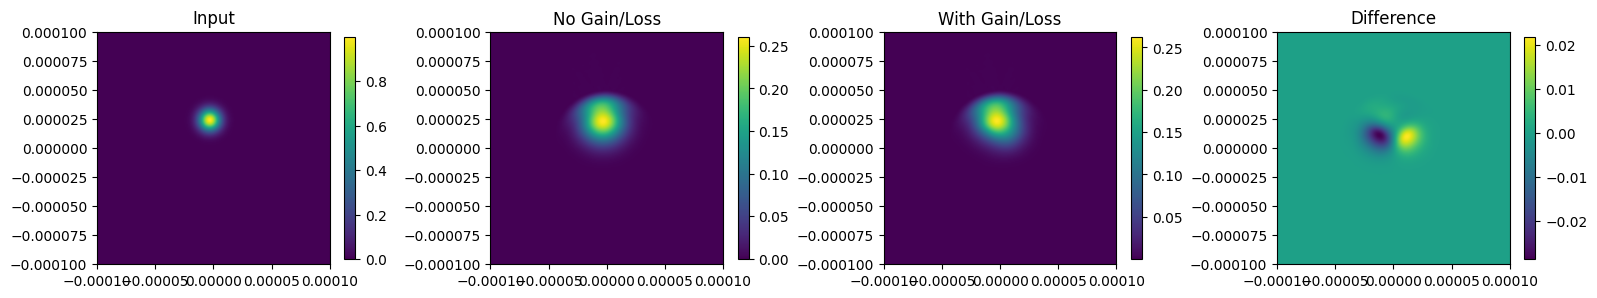

Power (no gain): 431.5458566081629
Power (with gain): 426.5451413424043


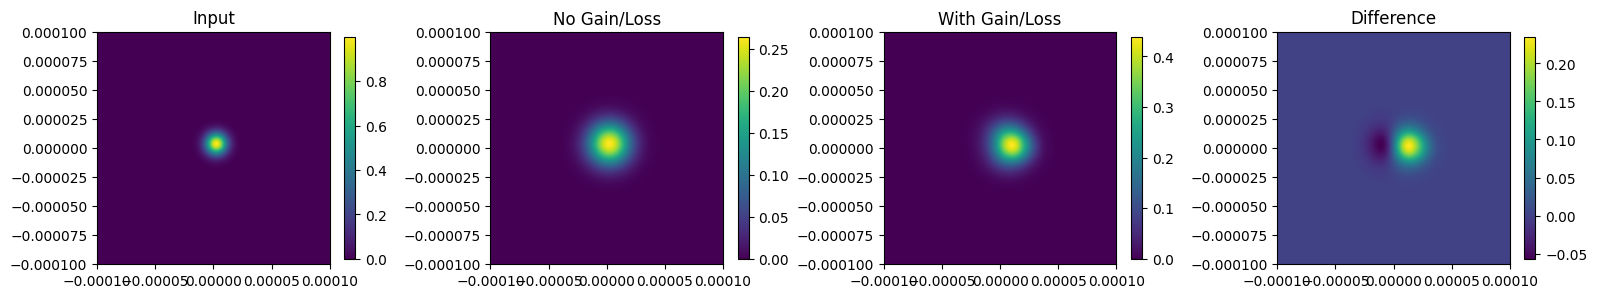

Power (no gain): 431.5458566081468
Power (with gain): 605.202216198628


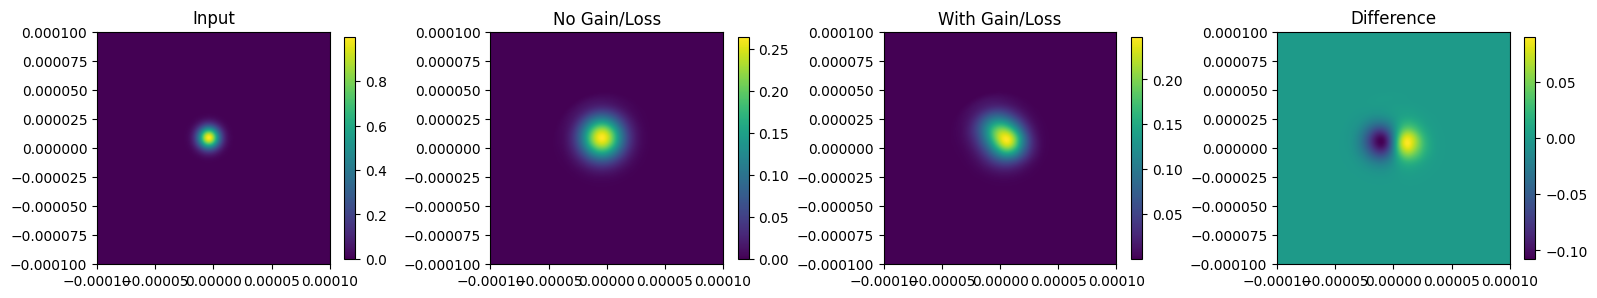

Power (no gain): 431.54585660817065
Power (with gain): 398.9359856062516


In [7]:
# - No modification necessary -

def compare_gain_vs_no_gain(input_field, alpha0):

    n_gain, n_ref, _ = create_multimode_fiber(alpha0=alpha0)
    n_passive, _, _ = create_multimode_fiber(alpha0=0.0)

    field_gain = propagate(input_field, n_gain, n_ref)
    field_passive = propagate(input_field, n_passive, n_ref)

    plt.figure(figsize=(16, 4))
    
    plt.subplot(1, 4, 1)
    plt.imshow(np.abs(input_field)**2, extent=[x.min(), x.max(), y.min(), y.max()])
    plt.title("Input")
    plt.colorbar(shrink=0.6)

    plt.subplot(1, 4, 2)
    plt.imshow(np.abs(field_passive)**2, extent=[x.min(), x.max(), y.min(), y.max()])
    plt.title("No Gain/Loss")
    plt.colorbar(shrink=0.6)

    plt.subplot(1, 4, 3)
    plt.imshow(np.abs(field_gain)**2, extent=[x.min(), x.max(), y.min(), y.max()])
    plt.title("With Gain/Loss")
    plt.colorbar(shrink=0.6)

    plt.subplot(1, 4, 4)
    plt.imshow(np.abs(field_gain)**2 - np.abs(field_passive)**2, extent=[x.min(), x.max(), y.min(), y.max()])
    plt.title("Difference")
    plt.colorbar(shrink=0.6)

    plt.tight_layout()
    plt.show()

    print("Power (no gain):", np.sum(np.abs(field_passive)**2))
    print("Power (with gain):", np.sum(np.abs(field_gain)**2))
    
np.random.seed(2)
for i in range(3):
    compare_gain_vs_no_gain(generate_random_location_gaussian_beam(), alpha0=50*(25^i))

## Discussion
1) The presence of the gain and loss regions appear to push the beam towards the right side of the fiber, which we can clearly see visualized in the difference plots which show and increase in intensity on the right and a decrease in intensity on the left.
2) In a conventional sense, it is not fair to call this behavior guiding. Guided modes should be eigenmodes that do not change in profile (although they may scale). The gain regions produce a scaling effect but do not actually contain the wave profile.
3) Yes it is still possible, as this system would still be PT symmetric, but we cannot guarantee without further analysis.

# Part 3

Now that you have created your PT symmetric fiber and tested its properties, it is time to try the phase conjugation method with it. 

You will first try the traditional approach of just phase conjugating the field and propagating it through the fiber again. To do this, implement the function simulate_fiber_phase_conjugation. Then you will correct this to work for your setup by adding in a rotation of 180 degrees to the field on top of the phase conjugation. This will be implemented in the function simulate_fiber_phase_conjugation_and_rotation. Both of these functions should take the gain coefficient as inputs and return the randomly generated input field and the reconstructed output field as outputs.

After you have implemented these two functions, you may run the provided plotting code to verify that their outputs match your expectations.

Then, answer the following question:
1) Why is the rotation crucial to making this method work?

In [8]:
def simulate_fiber_phase_conjugation(alpha0):
    n, n_ref, alpha = create_multimode_fiber(alpha0=alpha0)
    
    input_field = generate_random_location_gaussian_beam()
    output_field = propagate(input_field, n, n_ref)
    conjugated = np.conj(output_field)
    reconstructed = propagate(conjugated, n, n_ref)
    
    return input_field, reconstructed

In [9]:
# - No modification necessary -

def run_phase_conjugation_simulation(alpha0):
    np.random.seed(2)
    
    input_field, reconstructed = simulate_fiber_phase_conjugation(alpha0)
    target_field = np.rot90(input_field, 2)
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(np.abs(input_field)**2)
    plt.title("Intensity of Input")
    plt.colorbar(shrink=0.6)
    
    plt.subplot(1, 3, 2)
    plt.imshow(np.abs(reconstructed)**2)
    plt.title("Intensity of Reconstruction")
    plt.colorbar(shrink=0.6)
    
    plt.subplot(1, 3, 3)
    plt.imshow(np.abs(target_field)**2)
    plt.title("Intensity of Target")
    plt.colorbar(shrink=0.6)
    
    plt.tight_layout()
    plt.show()
    
    error = np.mean(np.abs(reconstructed - target_field))
    print(f"Reconstruction error: {error:.5e}")
    
interact(
    run_phase_conjugation_simulation,
    alpha0=FloatSlider(
        value=2000.0,
        min=0.0,
        max=20000.0,
        step=500.0,
        description='|α| (1/m)'
    )
)   

interactive(children=(FloatSlider(value=2000.0, description='|α| (1/m)', max=20000.0, step=500.0), Output()), …

<function __main__.run_phase_conjugation_simulation(alpha0)>

In [10]:
def simulate_fiber_phase_conjugation_and_rotation(alpha0):
    n, n_ref, alpha = create_multimode_fiber(alpha0=alpha0)
    
    input_field = generate_random_location_gaussian_beam()
    output_field = propagate(input_field, n, n_ref)
    conjugated = np.rot90(np.conj(output_field), 2)
    reconstructed = propagate(conjugated, n, n_ref)
    
    return input_field, reconstructed

In [11]:
# - No modification necessary -

def run_phase_conjugation_and_rotation_simulation(alpha0):
    np.random.seed(2)
    
    input_field, reconstructed = simulate_fiber_phase_conjugation_and_rotation(alpha0)
    target_field = np.rot90(input_field, 2)
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(np.abs(input_field)**2)
    plt.title("Intensity of Input")
    plt.colorbar(shrink=0.6)
    
    plt.subplot(1, 3, 2)
    plt.imshow(np.abs(reconstructed)**2)
    plt.title("Intensity of Reconstruction")
    plt.colorbar(shrink=0.6)
    
    plt.subplot(1, 3, 3)
    plt.imshow(np.abs(target_field)**2)
    plt.title("Intensity of Target")
    plt.colorbar(shrink=0.6)
    
    plt.tight_layout()
    plt.show()
    
    error = np.mean(np.abs(reconstructed - target_field))
    print(f"Reconstruction error: {error:.5e}")
    
interact(
    run_phase_conjugation_and_rotation_simulation,
    alpha0=FloatSlider(
        value=2000.0,
        min=0.0,
        max=20000.0,
        step=500.0,
        description='|α| (1/m)'
    )
)   

interactive(children=(FloatSlider(value=2000.0, description='|α| (1/m)', max=20000.0, step=500.0), Output()), …

<function __main__.run_phase_conjugation_and_rotation_simulation(alpha0)>

## Discussion
1) To undo the effects of propagating through the system, we want to backpropagate the field through the refractive index profile $n^*(x,y)$. This way, all loss and gain will be undone. When we take the phase conjugate of the field, this only reverses the direction of propagation. It does not affect the refractive index distribution of the fiber. This means that if we were to directly propagate from this position, instead of undoing the effects of gain and loss we would double them. From the definition of PT symmetry, we know that $n^*(x,y) = n(-x,-y)$, so we choose to use a rotation to introduce an effective complex conjugate operation on the refractive index and allow us to retrieve our original object. 

# Bonus
Imagine you are building a scanning florescence-based imaging system using this fiber. What advantages does using this special type of fiber bring and how would you use it? Why couldn't we use a fiber that just had gain instead of gain and loss?

## Discussion
This fiber would be useful for a florescence imaging system because the gain in the system would allow us to deliver a large amount of power to excite florescence at targeted spots. To do this, we could choose to use an input illumination that primarily goes through the region of the fiber with high gain. Because our system is PT symmetric, we can still do our normal optimization for minimal spot size, which is something we couldn't do if the system only had gain. By physically scanning the fiber instead of trying to scan through the fiber, we could use our high gain single spot for all spatial coordinates in our imaging system. This will give us better SNR on our returning information than a conventional fiber, and as such improve the quality of the image.